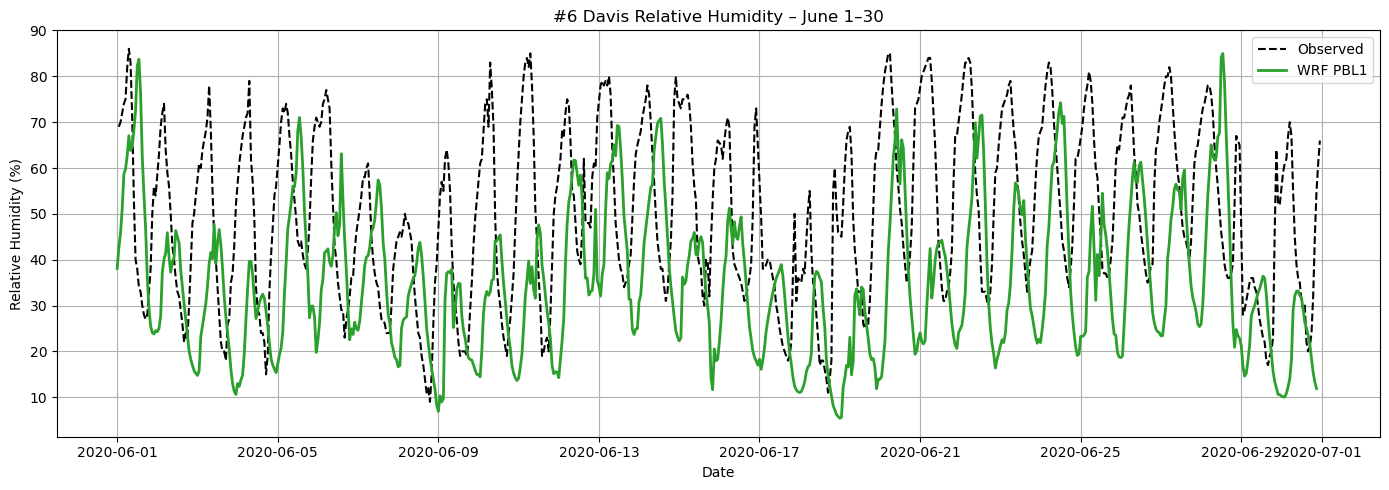

3648    69.0
3649    70.0
3650    72.0
3651    74.0
3652    75.0
        ... 
4362    32.0
4363    45.0
4364    55.0
4365    61.0
4366    66.0
Name: Relative Humidity (%), Length: 690, dtype: float64


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from wrf import getvar, to_np, ll_to_xy, ALL_TIMES
from glob import glob

# === Target location ===
lat_point = 38.535694
lon_point = -121.77636

# === WRF Settings ===
Var = "rh"
VarLabel = "Relative Humidity (%)"
data_paths = [("/data/wto/WRFOUT/Sac_NDown_UCM1_PBL1/", "WRF PBL1","tab:green")]

# === Containers ===
Var_all = [[] for _ in data_paths]
Time_all = []

# === Get files and grid index ===
all_files = [sorted(glob(f"{path}/wrfout_d01_2020-06-*")) for path, _, _ in data_paths]
sample_ds = Dataset(all_files[0][0])
x_idx, y_idx = map(int, ll_to_xy(sample_ds, lat_point, lon_point, as_int=True))

# === WRF file loop ===
for file_i in range(len(all_files[0])):
    datasets = [Dataset(files[file_i]) for files in all_files]

    time_vals = getvar(datasets[0], "times", timeidx=ALL_TIMES)
    time_vals_np = to_np(time_vals)

    if np.isscalar(time_vals_np):
        time_vals_np = [time_vals_np]
    elif isinstance(time_vals_np, np.ndarray) and time_vals_np.ndim == 0:
        time_vals_np = [time_vals_np.item()]
    else:
        time_vals_np = list(time_vals_np)

    for t, time_val in enumerate(time_vals_np):
        Time_all.append(pd.to_datetime(str(time_val)))

        for j, ds in enumerate(datasets):
            var = getvar(ds, Var, timeidx=ALL_TIMES)
            var_np = to_np(var)

            if var_np.ndim == 3:
                value = var_np[t, y_idx, x_idx]
            elif var_np.ndim == 2:
                value = var_np[y_idx, x_idx]
            else:
                raise ValueError(f"Unexpected var shape: {var_np.shape}")

            Var_all[j].append(value)


# === Filter WRF June data ===
Time_all = pd.to_datetime(Time_all)
time_range_june1_30 = (Time_all >= pd.Timestamp("2020-06-01")) & (Time_all < pd.Timestamp("2020-07-01"))

# === Load and parse observed data ===
df = pd.read_csv("/home/mpasillaspablo/CIMIS/6_Davis_hly2020.csv", dtype=str)

# -- Combine and clean 'Date' + 'Hour' (or similar) columns --
# Example: columns are "Date" and "Hour" separately
date_strs = df["Date"].str.strip()
hour_strs = df["Hour (PST)"].str.zfill(4).str.replace(r"(\d{2})(\d{2})", r"\1:\2", regex=True)
df["DateTime"] = pd.to_datetime(date_strs + " " + hour_strs, format="%m/%d/%Y %H:%M", errors="coerce")

# -- Extract and clean RH values --
raw_rh = df.iloc[:, 16].str.extract(r"(\d{1,3})")[0]
valid_rh = pd.to_numeric(raw_rh, errors="coerce")
valid_rh = valid_rh[(valid_rh >= 0) & (valid_rh <= 100)]

df_valid = df.loc[valid_rh.index].copy()
df_valid["Relative Humidity (%)"] = valid_rh
df_valid = df_valid.dropna(subset=["DateTime", "Relative Humidity (%)"])
df_valid = df_valid[(df_valid["DateTime"] >= "2020-06-01") & (df_valid["DateTime"] < "2020-07-01")]

# === Plot ===
fig, ax = plt.subplots(figsize=(14, 5))

# Observed
ax.plot(df_valid["DateTime"], df_valid["Relative Humidity (%)"],
        color="black", linestyle="--", label="Observed", linewidth=1.5)

# WRF
for i, (_, label, color) in enumerate(data_paths):
    ax.plot(np.array(Time_all)[time_range_june1_30],
            np.array(Var_all[i])[time_range_june1_30],
            label=label, color=color, linewidth=2)

ax.set_title("#6 Davis Relative Humidity – June 1–30")
ax.set_xlabel("Date")
ax.set_ylabel("Relative Humidity (%)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

print(df_valid["Relative Humidity (%)"])

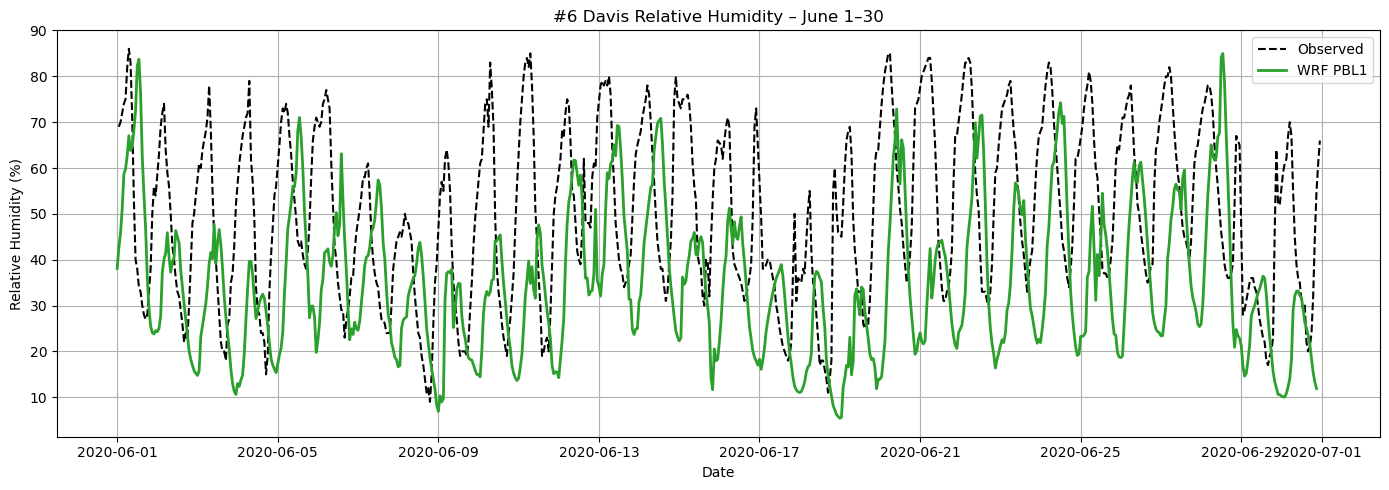

Mean and RMS Relative Humidity (Interpolated to Obs Times):
Observed:
  Mean Relative Humidity:  49.90
  RMS  Relative Humidity:  35.96

WRF PBL1:
  Mean Relative Humidity:  35.51
  RMS  Relative Humidity:  15.92

RMSE (Model vs Observed):
WRF PBL1: RMSE = 27.88


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from wrf import getvar, to_np, ll_to_xy, ALL_TIMES
from glob import glob

# === Target location ===
lat_point = 38.535694
lon_point = -121.77636

# === WRF Settings ===
Var = "rh"
VarLabel = "Relative Humidity (%)"
data_paths = [("/data/wto/WRFOUT/Sac_NDown_UCM1_PBL1/", "WRF PBL1","tab:green")]

# === Containers ===
Var_all = [[] for _ in data_paths]
Time_all = []

# === Get files and grid index ===
all_files = [sorted(glob(f"{path}/wrfout_d01_2020-06-*")) for path, _, _ in data_paths]
sample_ds = Dataset(all_files[0][0])
x_idx, y_idx = map(int, ll_to_xy(sample_ds, lat_point, lon_point, as_int=True))

# === WRF file loop ===
for file_i in range(len(all_files[0])):
    datasets = [Dataset(files[file_i]) for files in all_files]

    time_vals = getvar(datasets[0], "times", timeidx=ALL_TIMES)
    time_vals_np = to_np(time_vals)

    if np.isscalar(time_vals_np):
        time_vals_np = [time_vals_np]
    elif isinstance(time_vals_np, np.ndarray) and time_vals_np.ndim == 0:
        time_vals_np = [time_vals_np.item()]
    else:
        time_vals_np = list(time_vals_np)

    for t, time_val in enumerate(time_vals_np):
        Time_all.append(pd.to_datetime(str(time_val)))

        for j, ds in enumerate(datasets):
            var = getvar(ds, Var, timeidx=ALL_TIMES)
            var_np = to_np(var)

            if var_np.ndim == 3:
                value = var_np[t, y_idx, x_idx]
            elif var_np.ndim == 2:
                value = var_np[y_idx, x_idx]
            else:
                raise ValueError(f"Unexpected var shape: {var_np.shape}")

            Var_all[j].append(value)


# === Filter WRF June data ===
Time_all = pd.to_datetime(Time_all)
time_range_june1_30 = (Time_all >= pd.Timestamp("2020-06-01")) & (Time_all < pd.Timestamp("2020-07-01"))

# === Load and parse observed data ===
df = pd.read_csv("/home/mpasillaspablo/CIMIS/6_Davis_hly2020.csv", dtype=str)

# -- Combine and clean 'Date' + 'Hour' (or similar) columns --
# Example: columns are "Date" and "Hour" separately
date_strs = df["Date"].str.strip()
hour_strs = df["Hour (PST)"].str.zfill(4).str.replace(r"(\d{2})(\d{2})", r"\1:\2", regex=True)
df["DateTime"] = pd.to_datetime(date_strs + " " + hour_strs, format="%m/%d/%Y %H:%M", errors="coerce")

# -- Extract and clean RH values --
raw_rh = df.iloc[:, 16].str.extract(r"(\d{1,3})")[0]
valid_rh = pd.to_numeric(raw_rh, errors="coerce")
valid_rh = valid_rh[(valid_rh >= 0) & (valid_rh <= 100)]

df_valid = df.loc[valid_rh.index].copy()
df_valid["Relative Humidity (%)"] = valid_rh
df_valid = df_valid.dropna(subset=["DateTime", "Relative Humidity (%)"])
df_valid = df_valid[(df_valid["DateTime"] >= "2020-06-01") & (df_valid["DateTime"] < "2020-07-01")]

# === Plot ===
fig, ax = plt.subplots(figsize=(14, 5))

# Observed
ax.plot(df_valid["DateTime"], df_valid["Relative Humidity (%)"],
        color="black", linestyle="--", label="Observed", linewidth=1.5)

# WRF
for i, (_, label, color) in enumerate(data_paths):
    ax.plot(np.array(Time_all)[time_range_june1_30],
            np.array(Var_all[i])[time_range_june1_30],
            label=label, color=color, linewidth=2)

ax.set_title("#6 Davis Relative Humidity – June 1–30")
ax.set_xlabel("Date")
ax.set_ylabel("Relative Humidity (%)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


from sklearn.metrics import mean_squared_error

# === Interpolate WRF to observed times ===
wrf_pbl1_series = pd.Series(np.array(Var_all[0])[time_range_june1_30], index=Time_all[time_range_june1_30])
interp_wrf_to_obs = wrf_pbl1_series.reindex(df_valid["DateTime"], method='nearest')

# Drop any NaNs due to gaps in time alignment
obs_rh = df_valid["Relative Humidity (%)"].to_numpy()
mod_rh = interp_wrf_to_obs.to_numpy()
valid_mask = ~np.isnan(mod_rh) & ~np.isnan(obs_rh)
obs_rh = obs_rh[valid_mask]
mod_rh = mod_rh[valid_mask]


# === Compute statistics ===
# Observed
obs_mean = np.nanmean(obs_rh)
obs_rms = np.sqrt(np.nanmean(np.square(series)))

# WRF PBL1
mod_mean = np.nanmean(mod_rh)
mod_rms = np.nanstd(mod_rh)

# RMSE
rmse = np.sqrt(mean_squared_error(obs_rh, mod_rh))

# === Print results ===
print("Mean and RMS Relative Humidity (Interpolated to Obs Times):")
print("Observed:")
print(f"  Mean Relative Humidity:  {obs_mean:.2f}")
print(f"  RMS  Relative Humidity:  {obs_rms:.2f}\n")

print("WRF PBL1:")
print(f"  Mean Relative Humidity:  {mod_mean:.2f}")
print(f"  RMS  Relative Humidity:  {mod_rms:.2f}\n")

print("RMSE (Model vs Observed):")
print(f"WRF PBL1: RMSE = {rmse:.2f}")


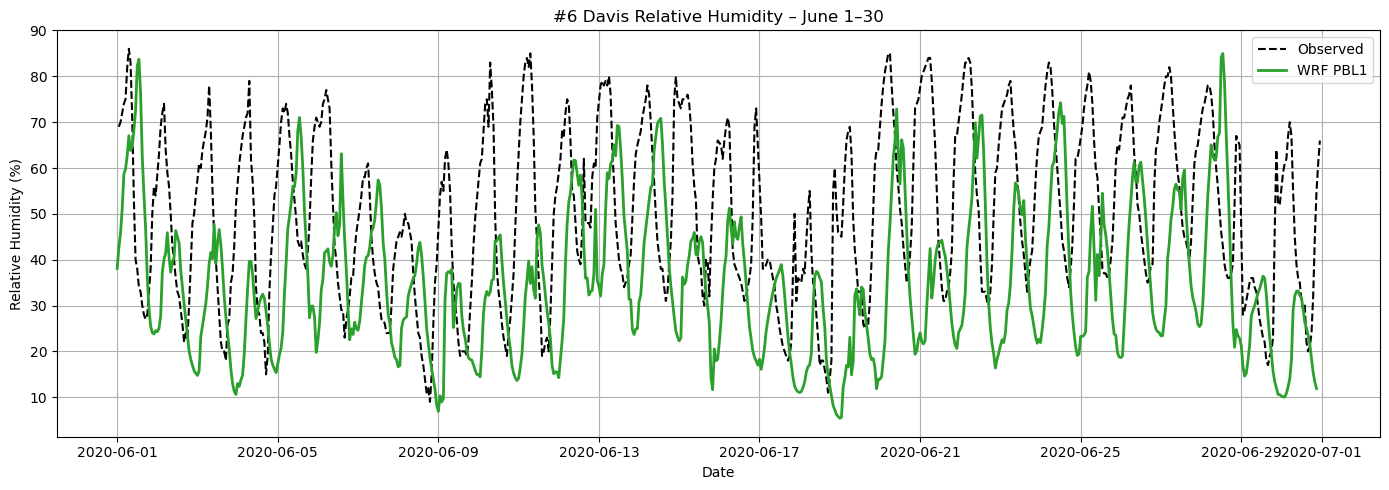

Mean and RMS Relative Humidity (Interpolated to Obs Times):
Observed:
  Mean Relative Humidity:  49.90
  RMS  Relative Humidity:  53.33

WRF PBL1:
  Mean Relative Humidity:  35.51
  RMS  Relative Humidity:  15.92

RMSE (Model vs Observed):
WRF PBL1: RMSE = 28.67


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from wrf import getvar, to_np, ll_to_xy, ALL_TIMES
from glob import glob

# === Target location ===
lat_point = 38.535694
lon_point = -121.77636

# === WRF Settings ===
Var = "rh"
VarLabel = "Relative Humidity (%)"
data_paths = [("/data/wto/WRFOUT/Sac_NDown_UCM1_PBL1/", "WRF PBL1","tab:green")]

# === Containers ===
Var_all = [[] for _ in data_paths]
Time_all = []

# === Get files and grid index ===
all_files = [sorted(glob(f"{path}/wrfout_d01_2020-06-*")) for path, _, _ in data_paths]
sample_ds = Dataset(all_files[0][0])
x_idx, y_idx = map(int, ll_to_xy(sample_ds, lat_point, lon_point, as_int=True))

# === WRF file loop ===
for file_i in range(len(all_files[0])):
    datasets = [Dataset(files[file_i]) for files in all_files]

    time_vals = getvar(datasets[0], "times", timeidx=ALL_TIMES)
    time_vals_np = to_np(time_vals)

    if np.isscalar(time_vals_np):
        time_vals_np = [time_vals_np]
    elif isinstance(time_vals_np, np.ndarray) and time_vals_np.ndim == 0:
        time_vals_np = [time_vals_np.item()]
    else:
        time_vals_np = list(time_vals_np)

    for t, time_val in enumerate(time_vals_np):
        Time_all.append(pd.to_datetime(str(time_val)))

        for j, ds in enumerate(datasets):
            var = getvar(ds, Var, timeidx=ALL_TIMES)
            var_np = to_np(var)

            if var_np.ndim == 3:
                value = var_np[t, y_idx, x_idx]
            elif var_np.ndim == 2:
                value = var_np[y_idx, x_idx]
            else:
                raise ValueError(f"Unexpected var shape: {var_np.shape}")

            Var_all[j].append(value)


# === Filter WRF June data ===
Time_all = pd.to_datetime(Time_all)
time_range_june1_30 = (Time_all >= pd.Timestamp("2020-06-01")) & (Time_all < pd.Timestamp("2020-07-01"))

# === Load and parse observed data ===
df = pd.read_csv("/home/mpasillaspablo/CIMIS/6_Davis_hly2020.csv", dtype=str)

# -- Combine and clean 'Date' + 'Hour' (or similar) columns --
# Example: columns are "Date" and "Hour" separately
date_strs = df["Date"].str.strip()
hour_strs = df["Hour (PST)"].str.zfill(4).str.replace(r"(\d{2})(\d{2})", r"\1:\2", regex=True)
df["DateTime"] = pd.to_datetime(date_strs + " " + hour_strs, format="%m/%d/%Y %H:%M", errors="coerce")

# -- Extract and clean RH values --
raw_rh = df.iloc[:, 16].str.extract(r"(\d{1,3})")[0]
valid_rh = pd.to_numeric(raw_rh, errors="coerce")
valid_rh = valid_rh[(valid_rh >= 0) & (valid_rh <= 100)]

df_valid = df.loc[valid_rh.index].copy()
df_valid["Relative Humidity (%)"] = valid_rh
df_valid = df_valid.dropna(subset=["DateTime", "Relative Humidity (%)"])
df_valid = df_valid[(df_valid["DateTime"] >= "2020-06-01") & (df_valid["DateTime"] < "2020-07-01")]

# === Plot ===
fig, ax = plt.subplots(figsize=(14, 5))

# Observed
ax.plot(df_valid["DateTime"], df_valid["Relative Humidity (%)"],
        color="black", linestyle="--", label="Observed", linewidth=1.5)

# WRF
for i, (_, label, color) in enumerate(data_paths):
    ax.plot(np.array(Time_all)[time_range_june1_30],
            np.array(Var_all[i])[time_range_june1_30],
            label=label, color=color, linewidth=2)

ax.set_title("#6 Davis Relative Humidity – June 1–30")
ax.set_xlabel("Date")
ax.set_ylabel("Relative Humidity (%)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


from sklearn.metrics import mean_squared_error


# === Align model and observed data using time index ===
# Round to the nearest hour for matching (use lowercase 'h')
df_obs["DateTime_rounded"] = df_obs["DateTime"].dt.round("h")

# Create time-indexed series for each model
model_series = []
for data in var_all:
    index = pd.to_datetime(np.array(time_all)[june_mask]).round("h")  # round the datetime index
    series = pd.Series(np.array(data)[june_mask], index=index)
    model_series.append(series)


# Reindex models to observation times
model_aligned = [s.reindex(obs_series.index, method='nearest') for s in model_series]

# Drop any time points with missing values
valid_idx = obs_series.index.intersection(model_aligned[0].dropna().index)
for s in model_aligned[1:]:
    valid_idx = valid_idx.intersection(s.dropna().index)

obs_aligned = obs_series.loc[valid_idx]
models_aligned = [s.loc[valid_idx] for s in model_aligned]

def mean_rms(series):
    mean_val = np.nanmean(series)
    rms_val = np.sqrt(np.nanmean(np.square(series)))
    return mean_val, rms_val

# === Calculate statistics ===
obs_mean, obs_rms = mean_rms(obs_aligned)
model_stats = []
rmse_values = []

for model in models_aligned:
    m_mean, m_rms = mean_rms(model)
    rmse = np.sqrt(mean_squared_error(obs_aligned, model))
    model_stats.append((m_mean, m_rms))
    rmse_values.append(rmse)

# === Print results ===
print("Mean and RMS Relative Humidity (Interpolated to Obs Times):")
print("Observed:")
print(f"  Mean Relative Humidity:  {obs_mean:.2f}")
print(f"  RMS  Relative Humidity:  {obs_rms:.2f}\n")


print("WRF PBL1:")
print(f"  Mean Relative Humidity:  {mod_mean:.2f}")
print(f"  RMS  Relative Humidity:  {mod_rms:.2f}\n")

print("RMSE (Model vs Observed):")
print(f"WRF PBL1: RMSE = {rmse:.2f}")

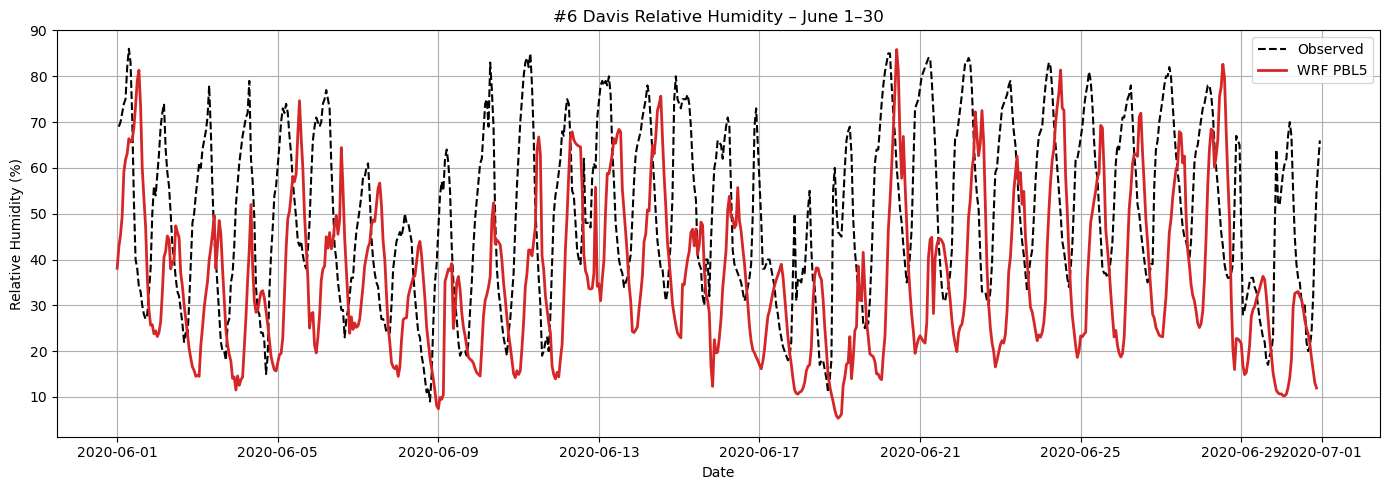

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from wrf import getvar, to_np, ll_to_xy, ALL_TIMES
from glob import glob

# === Target location ===
lat_point = 38.535694
lon_point = -121.77636

# === WRF Settings ===
Var = "rh"
VarLabel = "Relative Humidity (%)"
data_paths = [("/data/wto/WRFOUT/Sac_NDown_UCM1_PBL5/", "WRF PBL5","tab:red")]

# === Containers ===
Var_all = [[] for _ in data_paths]
Time_all = []

# === Get files and grid index ===
all_files = [sorted(glob(f"{path}/wrfout_d01_2020-06-*")) for path, _, _ in data_paths]
sample_ds = Dataset(all_files[0][0])
x_idx, y_idx = map(int, ll_to_xy(sample_ds, lat_point, lon_point, as_int=True))

# === WRF file loop ===
for file_i in range(len(all_files[0])):
    datasets = [Dataset(files[file_i]) for files in all_files]

    time_vals = getvar(datasets[0], "times", timeidx=ALL_TIMES)
    time_vals_np = to_np(time_vals)

    if np.isscalar(time_vals_np):
        time_vals_np = [time_vals_np]
    elif isinstance(time_vals_np, np.ndarray) and time_vals_np.ndim == 0:
        time_vals_np = [time_vals_np.item()]
    else:
        time_vals_np = list(time_vals_np)

    for t, time_val in enumerate(time_vals_np):
        Time_all.append(pd.to_datetime(str(time_val)))

        for j, ds in enumerate(datasets):
            var = getvar(ds, Var, timeidx=ALL_TIMES)
            var_np = to_np(var)

            if var_np.ndim == 3:
                value = var_np[t, y_idx, x_idx]
            elif var_np.ndim == 2:
                value = var_np[y_idx, x_idx]
            else:
                raise ValueError(f"Unexpected var shape: {var_np.shape}")

            Var_all[j].append(value)


# === Filter WRF June data ===
Time_all = pd.to_datetime(Time_all)
time_range_june1_30 = (Time_all >= pd.Timestamp("2020-06-01")) & (Time_all < pd.Timestamp("2020-07-01"))

# === Load and parse observed data ===
df = pd.read_csv("/home/mpasillaspablo/CIMIS/6_Davis_hly2020.csv", dtype=str)

# -- Combine and clean 'Date' + 'Hour' (or similar) columns --
# Example: columns are "Date" and "Hour" separately
date_strs = df["Date"].str.strip()
hour_strs = df["Hour (PST)"].str.zfill(4).str.replace(r"(\d{2})(\d{2})", r"\1:\2", regex=True)
df["DateTime"] = pd.to_datetime(date_strs + " " + hour_strs, format="%m/%d/%Y %H:%M", errors="coerce")

# -- Extract and clean RH values --
raw_rh = df.iloc[:, 16].str.extract(r"(\d{1,3})")[0]
valid_rh = pd.to_numeric(raw_rh, errors="coerce")
valid_rh = valid_rh[(valid_rh >= 0) & (valid_rh <= 100)]

df_valid = df.loc[valid_rh.index].copy()
df_valid["Relative Humidity (%)"] = valid_rh
df_valid = df_valid.dropna(subset=["DateTime", "Relative Humidity (%)"])
df_valid = df_valid[(df_valid["DateTime"] >= "2020-06-01") & (df_valid["DateTime"] < "2020-07-01")]

# === Plot ===
fig, ax = plt.subplots(figsize=(14, 5))

# Observed
ax.plot(df_valid["DateTime"], df_valid["Relative Humidity (%)"],
        color="black", linestyle="--", label="Observed", linewidth=1.5)

# WRF
for i, (_, label, color) in enumerate(data_paths):
    ax.plot(np.array(Time_all)[time_range_june1_30],
            np.array(Var_all[i])[time_range_june1_30],
            label=label, color=color, linewidth=2)

ax.set_title("#6 Davis Relative Humidity – June 1–30")
ax.set_xlabel("Date")
ax.set_ylabel("Relative Humidity (%)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()



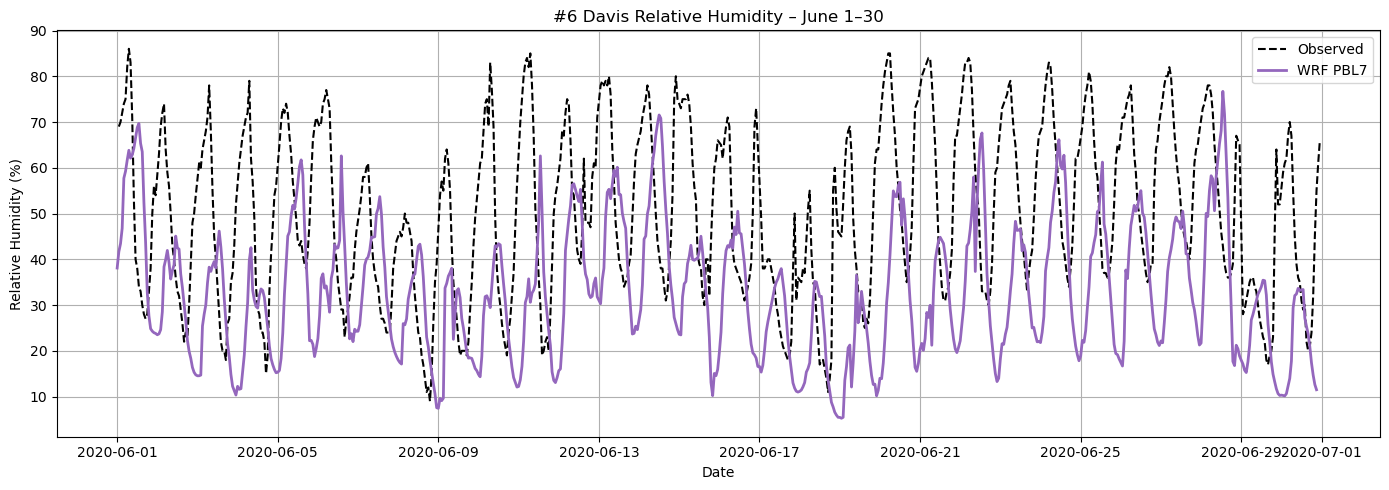

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from wrf import getvar, to_np, ll_to_xy, ALL_TIMES
from glob import glob

# === Target location ===
lat_point = 38.535694
lon_point = -121.77636

# === WRF Settings ===
Var = "rh"
VarLabel = "Relative Humidity (%)"
data_paths = [("/data/wto/WRFOUT/Sac_NDown_UCM1_PBL7/", "WRF PBL7","tab:purple")]

# === Containers ===
Var_all = [[] for _ in data_paths]
Time_all = []

# === Get files and grid index ===
all_files = [sorted(glob(f"{path}/wrfout_d01_2020-06-*")) for path, _, _ in data_paths]
sample_ds = Dataset(all_files[0][0])
x_idx, y_idx = map(int, ll_to_xy(sample_ds, lat_point, lon_point, as_int=True))

# === WRF file loop ===
for file_i in range(len(all_files[0])):
    datasets = [Dataset(files[file_i]) for files in all_files]

    time_vals = getvar(datasets[0], "times", timeidx=ALL_TIMES)
    time_vals_np = to_np(time_vals)

    if np.isscalar(time_vals_np):
        time_vals_np = [time_vals_np]
    elif isinstance(time_vals_np, np.ndarray) and time_vals_np.ndim == 0:
        time_vals_np = [time_vals_np.item()]
    else:
        time_vals_np = list(time_vals_np)

    for t, time_val in enumerate(time_vals_np):
        Time_all.append(pd.to_datetime(str(time_val)))

        for j, ds in enumerate(datasets):
            var = getvar(ds, Var, timeidx=ALL_TIMES)
            var_np = to_np(var)

            if var_np.ndim == 3:
                value = var_np[t, y_idx, x_idx]
            elif var_np.ndim == 2:
                value = var_np[y_idx, x_idx]
            else:
                raise ValueError(f"Unexpected var shape: {var_np.shape}")

            Var_all[j].append(value)


# === Filter WRF June data ===
Time_all = pd.to_datetime(Time_all)
time_range_june1_30 = (Time_all >= pd.Timestamp("2020-06-01")) & (Time_all < pd.Timestamp("2020-07-01"))

# === Load and parse observed data ===
df = pd.read_csv("/home/mpasillaspablo/CIMIS/6_Davis_hly2020.csv", dtype=str)

# -- Combine and clean 'Date' + 'Hour' (or similar) columns --
# Example: columns are "Date" and "Hour" separately
date_strs = df["Date"].str.strip()
hour_strs = df["Hour (PST)"].str.zfill(4).str.replace(r"(\d{2})(\d{2})", r"\1:\2", regex=True)
df["DateTime"] = pd.to_datetime(date_strs + " " + hour_strs, format="%m/%d/%Y %H:%M", errors="coerce")

# -- Extract and clean RH values --
raw_rh = df.iloc[:, 16].str.extract(r"(\d{1,3})")[0]
valid_rh = pd.to_numeric(raw_rh, errors="coerce")
valid_rh = valid_rh[(valid_rh >= 0) & (valid_rh <= 100)]

df_valid = df.loc[valid_rh.index].copy()
df_valid["Relative Humidity (%)"] = valid_rh
df_valid = df_valid.dropna(subset=["DateTime", "Relative Humidity (%)"])
df_valid = df_valid[(df_valid["DateTime"] >= "2020-06-01") & (df_valid["DateTime"] < "2020-07-01")]

# === Plot ===
fig, ax = plt.subplots(figsize=(14, 5))

# Observed
ax.plot(df_valid["DateTime"], df_valid["Relative Humidity (%)"],
        color="black", linestyle="--", label="Observed", linewidth=1.5)

# WRF
for i, (_, label, color) in enumerate(data_paths):
    ax.plot(np.array(Time_all)[time_range_june1_30],
            np.array(Var_all[i])[time_range_june1_30],
            label=label, color=color, linewidth=2)

ax.set_title("#6 Davis Relative Humidity – June 1–30")
ax.set_xlabel("Date")
ax.set_ylabel("Relative Humidity (%)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()



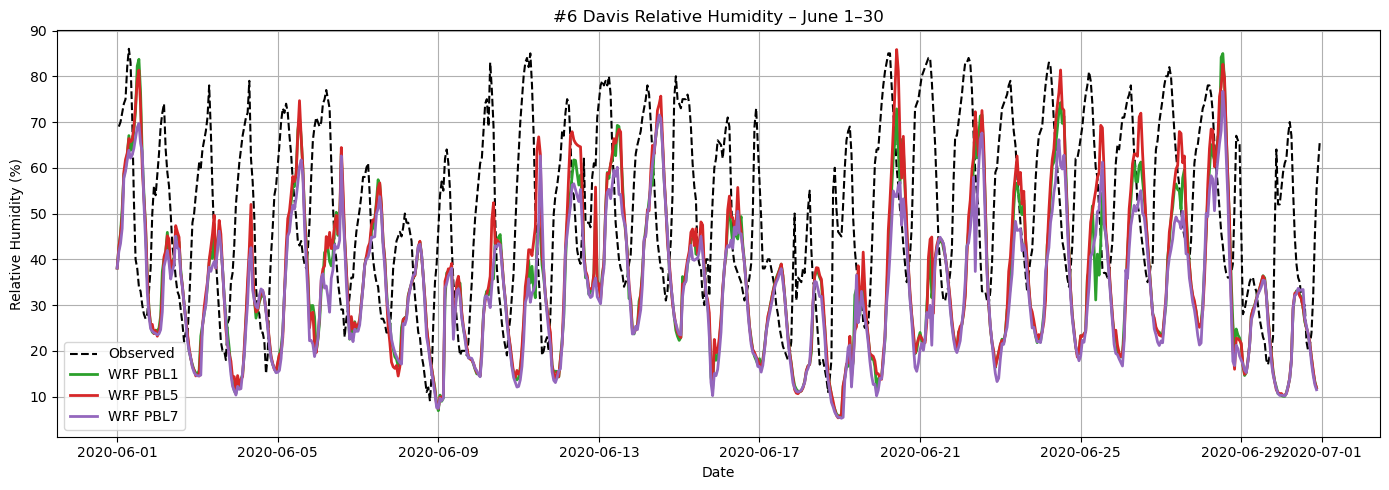

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from wrf import getvar, to_np, ll_to_xy, ALL_TIMES
from glob import glob

# === Target location ===
lat_point = 38.535694
lon_point = -121.77636

# === WRF Settings ===
var_name, var_label = "rh", "Relative Humidity (%)"
data_paths = [
    ("/data/wto/WRFOUT/Sac_NDown_UCM1_PBL1/", "WRF PBL1", 'tab:green'),
    ("/data/wto/WRFOUT/Sac_NDown_UCM1_PBL5/", "WRF PBL5", 'tab:red'),
    ("/data/wto/WRFOUT/Sac_NDown_UCM1_PBL7/", "WRF PBL7", 'tab:purple')
]

# === Containers ===
time_all = []
var_all = [[] for _ in data_paths]

# === Get files and grid index ===
wrf_files = [sorted(glob(f"{path}/wrfout_d01_2020-06-*")) for path, _, _ in data_paths]
x_idx, y_idx = map(int, ll_to_xy(Dataset(wrf_files[0][0]), lat_point, lon_point, as_int=True))


# === WRF file loop ===
for i in range(len(wrf_files[0])):
    datasets = [Dataset(f[i]) for f in wrf_files]
    times = to_np(getvar(datasets[0], "times", timeidx=ALL_TIMES))
    times = pd.to_datetime([str(t) for t in times])

    for t_idx, t in enumerate(times):
        time_all.append(t)

        for j, ds in enumerate(datasets):
            var = to_np(getvar(ds, var_name, timeidx=ALL_TIMES))
            val = var[t_idx, y_idx, x_idx] if var.ndim == 3 else var[y_idx, x_idx]
            var_all[j].append(val)

# === Filter WRF June data ===
time_all = pd.to_datetime(time_all)
june_mask = (time_all >= "2020-06-01") & (time_all < "2020-07-01")

# === Load and parse observed data ===
df_obs = pd.read_csv("/home/mpasillaspablo/CIMIS/6_Davis_hly2020.csv", dtype=str)

# -- Combine and clean 'Date' + 'Hour' (or similar) columns --
# Example: columns are "Date" and "Hour" separately
df_obs["DateTime"] = pd.to_datetime(
    df_obs["Date"].str.strip() + " " +
    df_obs["Hour (PST)"].str.zfill(4).str.replace(r"(\d{2})(\d{2})", r"\1:\2", regex=True),
    format="%m/%d/%Y %H:%M", errors="coerce"
)

# -- Extract and clean RH values --
rh = pd.to_numeric(df_obs.iloc[:, 16].str.extract(r"(\d{1,3})")[0], errors="coerce")
df_obs = df_obs.assign(**{var_label: rh}).dropna(subset=["DateTime", var_label])
df_obs = df_obs[(df_obs["DateTime"] >= "2020-06-01") & (df_obs["DateTime"] < "2020-07-01")]

# === Plot ===
fig, ax = plt.subplots(figsize=(14, 5))

# Observed
ax.plot(df_obs["DateTime"], df_obs[var_label], linestyle="--", color="black", label="Observed", linewidth=1.5)

# WRF
for data, (_, label, color) in zip(var_all, data_paths):
    ax.plot(np.array(time_all)[june_mask], np.array(data)[june_mask], label=label, color=color, lw=2)

ax.set(title="#6 Davis Relative Humidity – June 1–30", xlabel="Date", ylabel=var_label)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()



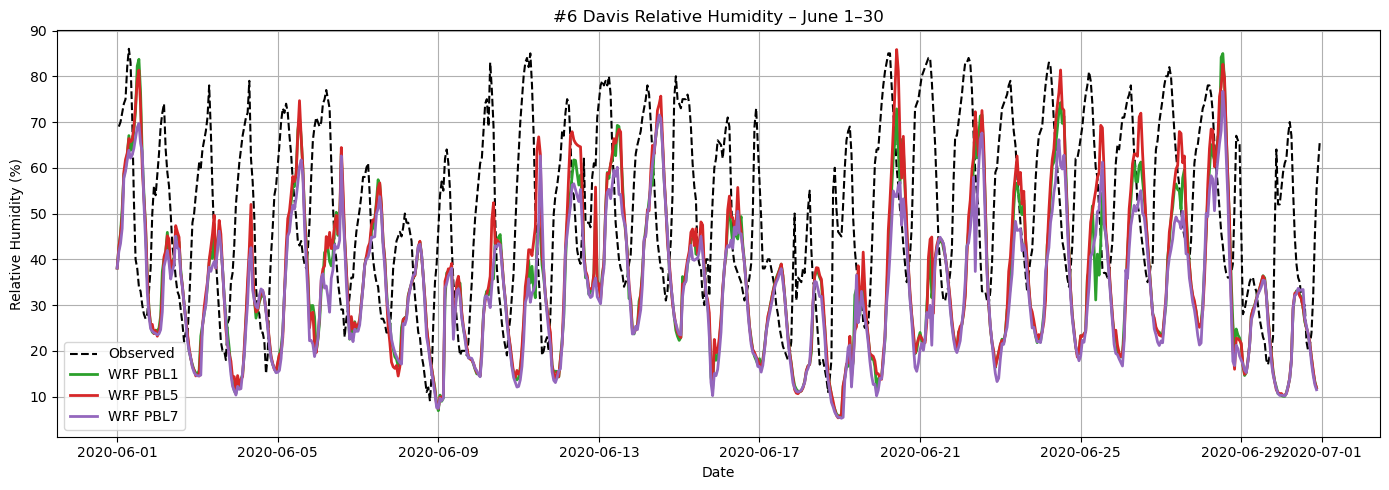

Mean and RMS Relative Humidity (Interpolated to Obs Times):
Observed:
  Mean Relative Humidity:  49.90
  RMS  Relative Humidity:  53.33

WRF PBL1:
  Mean Relative Humidity:  35.51
  RMS  Relative Humidity:  38.91

WRF PBL5:
  Mean Relative Humidity:  36.62
  RMS  Relative Humidity:  40.42

WRF PBL7:
  Mean Relative Humidity:  33.43
  RMS  Relative Humidity:  36.46

RMSE (Model vs Observed):
WRF PBL1: RMSE = 27.88
WRF PBL5: RMSE = 27.75
WRF PBL7: RMSE = 28.67


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from wrf import getvar, to_np, ll_to_xy, ALL_TIMES
from glob import glob
from sklearn.metrics import mean_squared_error

# === Target location ===
lat_point = 38.535694
lon_point = -121.77636

# === WRF Settings ===
var_name, var_label = "rh", "Relative Humidity (%)"
data_paths = [
    ("/data/wto/WRFOUT/Sac_NDown_UCM1_PBL1/", "WRF PBL1", 'tab:green'),
    ("/data/wto/WRFOUT/Sac_NDown_UCM1_PBL5/", "WRF PBL5", 'tab:red'),
    ("/data/wto/WRFOUT/Sac_NDown_UCM1_PBL7/", "WRF PBL7", 'tab:purple')
]

# === Containers ===
time_all = []
var_all = [[] for _ in data_paths]

# === Get files and grid index ===
wrf_files = [sorted(glob(f"{path}/wrfout_d01_2020-06-*")) for path, _, _ in data_paths]
x_idx, y_idx = map(int, ll_to_xy(Dataset(wrf_files[0][0]), lat_point, lon_point, as_int=True))


# === WRF file loop ===
for i in range(len(wrf_files[0])):
    datasets = [Dataset(f[i]) for f in wrf_files]
    times = to_np(getvar(datasets[0], "times", timeidx=ALL_TIMES))
    times = pd.to_datetime([str(t) for t in times])

    for t_idx, t in enumerate(times):
        time_all.append(t)

        for j, ds in enumerate(datasets):
            var = to_np(getvar(ds, var_name, timeidx=ALL_TIMES))
            val = var[t_idx, y_idx, x_idx] if var.ndim == 3 else var[y_idx, x_idx]
            var_all[j].append(val)

# === Filter WRF June data ===
time_all = pd.to_datetime(time_all)
june_mask = (time_all >= "2020-06-01") & (time_all < "2020-07-01")

# === Load and parse observed data ===
df_obs = pd.read_csv("/home/mpasillaspablo/CIMIS/6_Davis_hly2020.csv", dtype=str)

# -- Combine and clean 'Date' + 'Hour' (or similar) columns --
# Example: columns are "Date" and "Hour" separately
df_obs["DateTime"] = pd.to_datetime(
    df_obs["Date"].str.strip() + " " +
    df_obs["Hour (PST)"].str.zfill(4).str.replace(r"(\d{2})(\d{2})", r"\1:\2", regex=True),
    format="%m/%d/%Y %H:%M", errors="coerce"
)

# -- Extract and clean RH values --
rh = pd.to_numeric(df_obs.iloc[:, 16].str.extract(r"(\d{1,3})")[0], errors="coerce")
df_obs = df_obs.assign(**{var_label: rh}).dropna(subset=["DateTime", var_label])
df_obs = df_obs[(df_obs["DateTime"] >= "2020-06-01") & (df_obs["DateTime"] < "2020-07-01")]

# === Plot ===
fig, ax = plt.subplots(figsize=(14, 5))

# Observed
ax.plot(df_obs["DateTime"], df_obs[var_label], linestyle="--", color="black", label="Observed", linewidth=1.5)

# WRF
for data, (_, label, color) in zip(var_all, data_paths):
    ax.plot(np.array(time_all)[june_mask], np.array(data)[june_mask], label=label, color=color, lw=2)

ax.set(title="#6 Davis Relative Humidity – June 1–30", xlabel="Date", ylabel=var_label)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


# === Align model and observed data using time index ===
# Round to the nearest hour for matching (use lowercase 'h')
df_obs["DateTime_rounded"] = df_obs["DateTime"].dt.round("h")

# Create time-indexed series for each model
model_series = []
for data in var_all:
    index = pd.to_datetime(np.array(time_all)[june_mask]).round("h")  # round the datetime index
    series = pd.Series(np.array(data)[june_mask], index=index)
    model_series.append(series)


# Reindex models to observation times
model_aligned = [s.reindex(obs_series.index, method='nearest') for s in model_series]

# Drop any time points with missing values
valid_idx = obs_series.index.intersection(model_aligned[0].dropna().index)
for s in model_aligned[1:]:
    valid_idx = valid_idx.intersection(s.dropna().index)

obs_aligned = obs_series.loc[valid_idx]
models_aligned = [s.loc[valid_idx] for s in model_aligned]

def mean_rms(series):
    mean_val = np.nanmean(series)
    rms_val = np.sqrt(np.nanmean(np.square(series)))
    return mean_val, rms_val

# === Calculate statistics ===
obs_mean, obs_rms = mean_rms(obs_aligned)
model_stats = []
rmse_values = []

for model in models_aligned:
    m_mean, m_rms = mean_rms(model)
    rmse = np.sqrt(mean_squared_error(obs_aligned, model))
    model_stats.append((m_mean, m_rms))
    rmse_values.append(rmse)

# === Print results ===
print("Mean and RMS Relative Humidity (Interpolated to Obs Times):")
print("Observed:")
print(f"  Mean Relative Humidity:  {obs_mean:.2f}")
print(f"  RMS  Relative Humidity:  {obs_rms:.2f}\n")

labels = ["WRF PBL1", "WRF PBL5", "WRF PBL7"]
for label, (mean_val, rms_val) in zip(labels, model_stats):
    print(f"{label}:")
    print(f"  Mean Relative Humidity:  {mean_val:.2f}")
    print(f"  RMS  Relative Humidity:  {rms_val:.2f}\n")

print("RMSE (Model vs Observed):")
for label, rmse in zip(labels, rmse_values):
    print(f"{label}: RMSE = {rmse:.2f}")